In [1]:
from utils import*

In [2]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

rns_scope = list(df_rns_folditer.index)
cpds_scope = list(df_cpds_folditer.index)
rn2rules_scope = {k:v for k,v in rn2rules.items() if k in rns_scope}
len(rn2rules_scope)

5730

In [3]:
all_rules = []
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        all_rules.append(rule)
len(all_rules), len(set(all_rules))

(7558, 763)

# x2rulesNum

In [4]:
x2rulesNum = csv2dict('../data/assets/xgroup2/xgroup2rulesNum.csv')
x2rulesNum_scope = {}
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        for x in rule:
            if x not in x2rulesNum_scope.keys():
                x2rulesNum_scope[x] = 1
            else:
                x2rulesNum_scope[x] += 1
x2rulesNum_scope.pop('spontaneous')
print(len(x2rulesNum_scope))

396


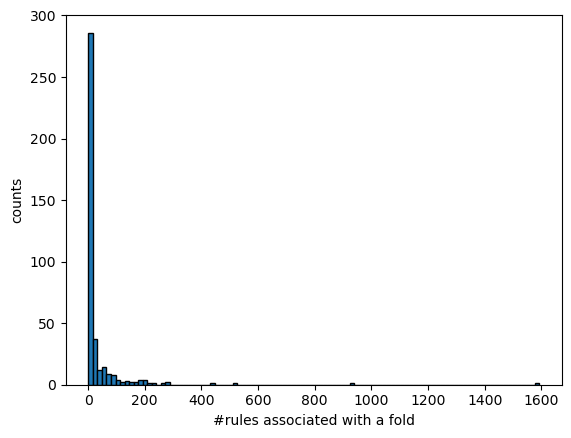

In [5]:
histogram(x2rulesNum_scope, bins=100, x_axis='#rules associated with a fold')

# rn2rules

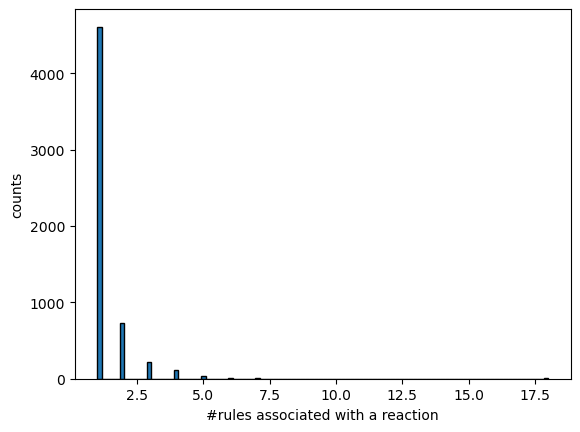

In [6]:
rn2rules_scopeNum = {k:len(v) for k,v in rn2rules_scope.items()}
histogram(rn2rules_scopeNum, bins=100, x_axis='#rules associated with a reaction')

763


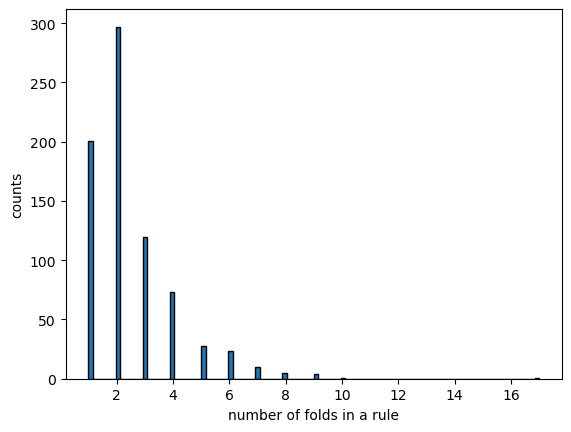

In [7]:
rule2len = {}
for rules in rn2rules_scope.values():
    for rule in rules:
        rule2len[rule] = len(rule)
print(len(rule2len))
histogram(rule2len, bins=100, x_axis='number of folds in a rule')

In [13]:
len([v if v < 6 else 6 for v in list(rule2len.values())])

763

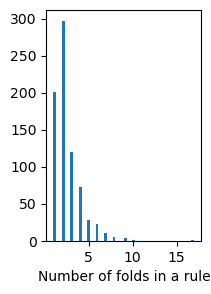

In [8]:
fig, ax = plt.subplots(figsize=(2, 3))
plt.hist(list(rule2len.values()), bins=50)
plt.xlabel('Number of folds in a rule')
# ax.set_yscale('log')

# plt.savefig('numFolds_per_rule.svg', dpi=300, bbox_inches='tight')
plt.show()

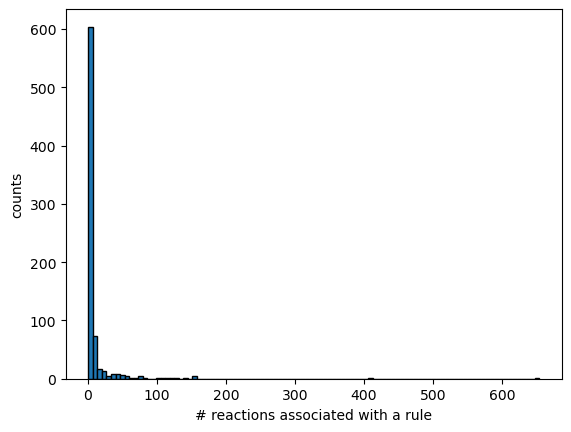

In [60]:
rule2rns = {}
for rn, rules in rn2rules_scope.items():
    for rule in rules:
        if rule not in rule2rns:
            rule2rns[rule] = [rn]
        else:
            rule2rns[rule].append(rn)
rule2rnsNum = {k:len(v) for k,v in rule2rns.items()}
histogram(rule2rnsNum, bins=100, x_axis='# reactions associated with a rule')

In [63]:
rule2rnsNum

{frozenset({'2002'}): 412,
 frozenset({'2003', '298'}): 57,
 frozenset({'2484'}): 104,
 frozenset({'2003'}): 654,
 frozenset({'2003', '304'}): 11,
 frozenset({'7560'}): 4,
 frozenset({'129', '2003'}): 59,
 frozenset({'5'}): 49,
 frozenset({'2003', '279'}): 50,
 frozenset({'7524'}): 99,
 frozenset({'2486'}): 52,
 frozenset({'11', '2002'}): 9,
 frozenset({'7524', '7531'}): 2,
 frozenset({'1', '2002', '304', '7531'}): 2,
 frozenset({'2003', '298', '7531'}): 3,
 frozenset({'2003', '298', '304', '7531'}): 3,
 frozenset({'304', '7531'}): 1,
 frozenset({'208', '3001'}): 1,
 frozenset({'286'}): 10,
 frozenset({'2003', '298', '304'}): 7,
 frozenset({'7579'}): 78,
 frozenset({'2007'}): 156,
 frozenset({'212'}): 13,
 frozenset({'206'}): 45,
 frozenset({'2006'}): 156,
 frozenset({'2002', '2003', '2007'}): 2,
 frozenset({'2003', '2007'}): 18,
 frozenset({'2002', '2003', '2004', '2007', '328', '4002'}): 7,
 frozenset({'129', '328'}): 2,
 frozenset({'328'}): 2,
 frozenset({'7523'}): 7,
 frozenset({'3